### Зачем нам визуализация?

Визуализация наглядно показывает тренды, паттерны и выбросы, которые тяжело увидеть в числах, особенно когда их много


[Пример](https://wjakethompson.com/blog/2017-05-05-datasaurus-dozen/)

### Какой график выбрать?

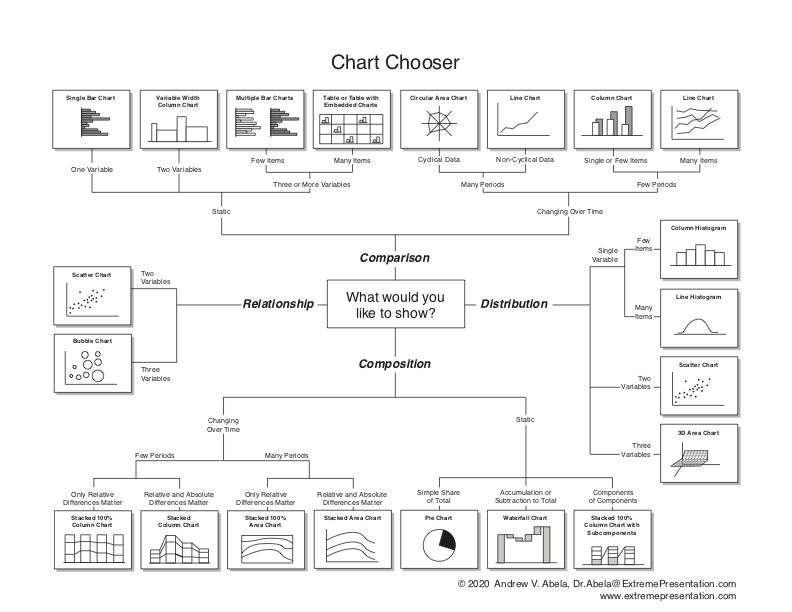

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from matplotlib.ticker import PercentFormatter
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

In [ ]:
np.random.seed(5)

### Подготовка данных и настройка стиля

In [ ]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 110
palette = {"Онлайн": "#3B6EA8", "В магазине": "#D98857"}
category_color = "#7A94B1"
accent_color = "#D26A4C"
neutral_color = "#B9C3CC"
random_generator = np.random.default_rng(17)

iris_bundle = load_iris(as_frame=True)
iris_data = iris_bundle.frame.rename(columns={"sepal length (cm)": "Длина чашелистика, см", "sepal width (cm)": "Ширина чашелистика, см", "petal length (cm)": "Длина лепестка, см", "petal width (cm)": "Ширина лепестка, см"}).copy()
iris_data["Вид"] = iris_data["target"].map(dict(enumerate(iris_bundle.target_names)))

month_dates = pd.date_range("2023-01-01", periods=36, freq="MS")
month_index = np.arange(len(month_dates))
season_pattern = np.sin(2 * np.pi * month_index / 12)
online_orders = np.rint(145 + 2.8 * month_index + 24 * season_pattern + random_generator.normal(0, 7, len(month_dates))).astype(int)
store_orders = np.rint(185 + 1.1 * month_index + 16 * season_pattern + random_generator.normal(0, 7, len(month_dates))).astype(int)
monthly_data = pd.DataFrame({"Месяц": month_dates, "Онлайн": online_orders, "В магазине": store_orders})
monthly_data["Всего заказов"] = monthly_data["Онлайн"] + monthly_data["В магазине"]
monthly_data["Год"] = monthly_data["Месяц"].dt.year
monthly_data["Номер месяца"] = monthly_data["Месяц"].dt.month

category_data = pd.DataFrame({"Категория": ["Основные блюда", "Напитки", "Десерты", "Закуски"], "Заказы": [120, 110, 105, 65]})
period_data = pd.DataFrame({"Категория": ["Основные блюда", "Напитки", "Десерты", "Закуски"], "Было": [105, 100, 98, 70], "Стало": [120, 110, 105, 65]})
word_counts = Counter({"данные": 20, "график": 16, "вопрос": 14, "сравнение": 11, "подписи": 9, "шкала": 8, "цвет": 7, "вывод": 6})

### Самое главное в визуализации

Вопрос важнее типа графика!

Перед любой визуализацией задайте себе ряд вопросов:
*   Что хотим показать?
*   Для кого предназначен график? Кто будет его смотреть?


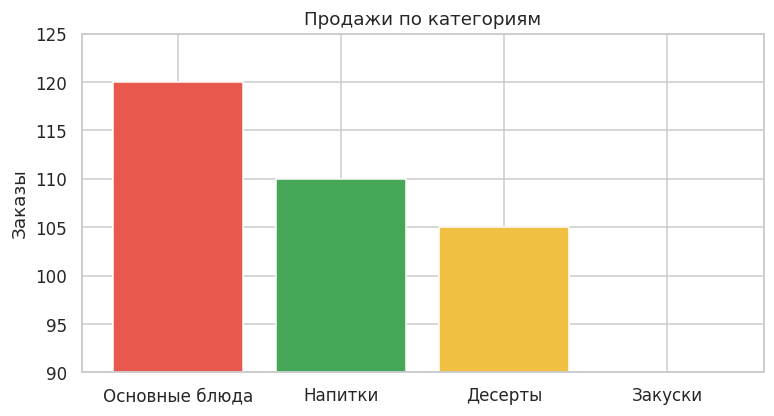

In [ ]:
figure = plt.figure(figsize=(8, 4))
axis = figure.add_subplot()
axis.bar(category_data["Категория"], category_data["Заказы"], color=["#E8584D", "#46A758", "#F1BF42", "#6F6FC5"])
axis.set_ylim(90, 125)
axis.set_title("Продажи по категориям")
axis.set_ylabel("Заказы")
plt.show()

*Этот график построен в Matplotlib

Matplotlib — библиотека на языке программирования Python для визуализации данных двумерной и трёхмерной графикой.

[Документация](https://matplotlib.org/stable/tutorials/index)

#### Какие проблемы у этого графика?

- Нижняя граница вертикальной оси равна 90, но глаз воспринимает **длины** столбцов: различия кажутся намного больше.
- Одна категория даже обрезана ниже нижней границы.
- Радужная палитра намекает, будто каждому цвету придан особый смысл, хотя наша задача - сравнение количеств.
- Если на столбчатой диаграмме величина закодирована длиной от общего основания - его нужно показывать. Если требуется рассмотреть маленькие различия внутри большого уровня, пригодятся точки на общей шкале или отдельный график разности.


#### Другой вариант

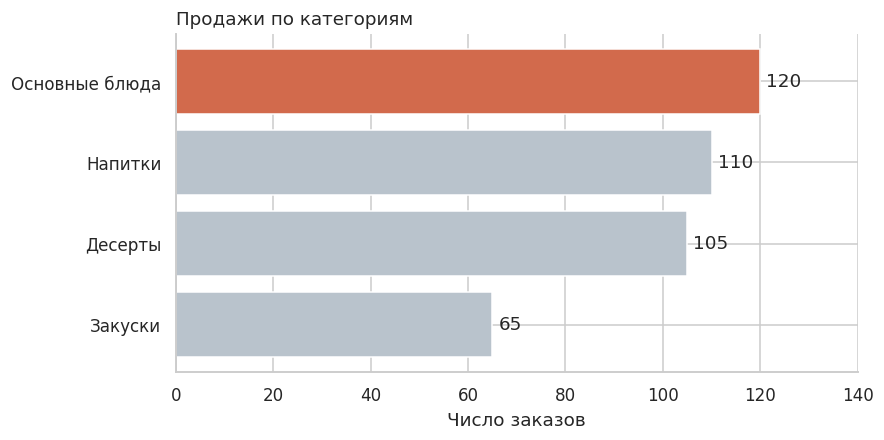

In [ ]:
sorted_categories = category_data.sort_values("Заказы")
figure = plt.figure(figsize=(8, 4))
axis = figure.add_subplot()
axis.barh(sorted_categories["Категория"], sorted_categories["Заказы"], color=[neutral_color, neutral_color, neutral_color, accent_color])
axis.set_xlim(0, 140)
axis.set_xlabel("Число заказов")
axis.set_title("Продажи по категориям", loc="left")
axis.bar_label(axis.containers[0], padding=4)
axis.spines[["top", "right"]].set_visible(False)
plt.show()

- Ось начинается с нуля
- Категории упорядочены
- Подписи стоят рядом со значениями и удобно читаются
- Цвет выделяет одну мысль

#### Уточняем маленькие значения

При старте оси с нуля хорошо виден размер категорий относительно нуля, но три верхние категории близки.

Если новый вопрос звучит *«насколько близки их значения?»*, точки на общей шкале могут оказаться понятнее.

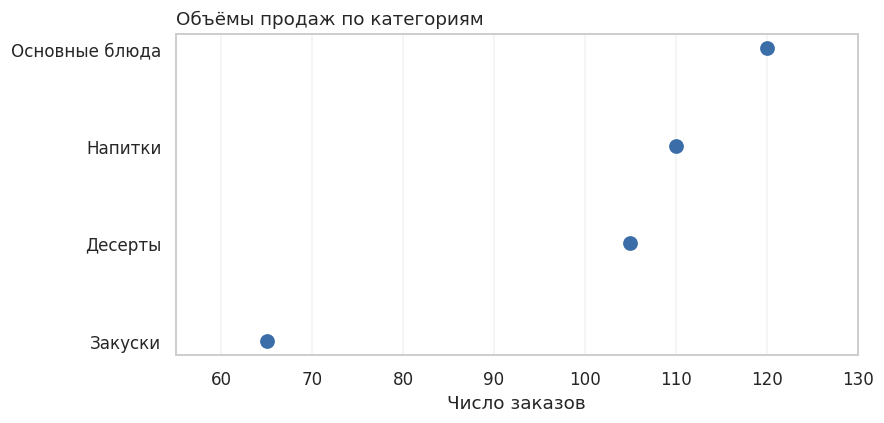

In [ ]:
figure = plt.figure(figsize=(8, 3.8))
axis = figure.add_subplot()
axis.scatter(sorted_categories["Заказы"], sorted_categories["Категория"], s=75, color="#3B6EA8", zorder=3)
axis.set_xlim(55, 130)
axis.set_xlabel("Число заказов")
axis.set_title("Объёмы продаж по категориям", loc="left")
axis.grid(axis="x", alpha=0.25)
axis.grid(axis="y", visible=False)
plt.show()

### Показываем время, непрерывность и целое/части

Линия подразумевает осмысленный порядок по горизонтальной оси и связь соседних положений.

В отличие от столбца, её не обязательно начинать с нуля: важно показать масштаб и не преувеличить небольшие колебания.

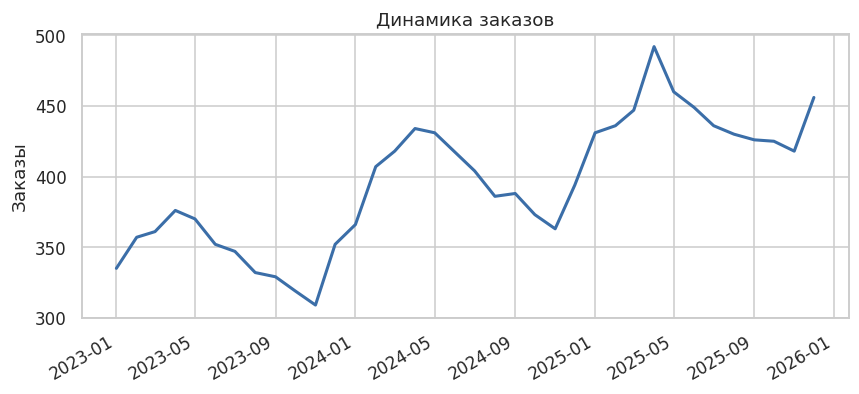

In [ ]:
orders_with_gap = monthly_data[["Месяц", "Всего заказов"]].copy()
missing_month = pd.Timestamp("2024-06-01")
orders_with_gap.loc[orders_with_gap["Месяц"] == missing_month, "Всего заказов"] = np.nan
figure = plt.figure(figsize=(9, 3.8))
axis = figure.add_subplot()
axis.plot(orders_with_gap.dropna()["Месяц"], orders_with_gap.dropna()["Всего заказов"], color=palette["Онлайн"], linewidth=2)
axis.set_title("Динамика заказов")
axis.set_ylabel("Заказы")
figure.autofmt_xdate()
plt.show()

На рисунке непрерывный отрезок от мая к июлю 2024 года создаёт впечатление, что июнь известен или изменение шло гладко. Это не так!

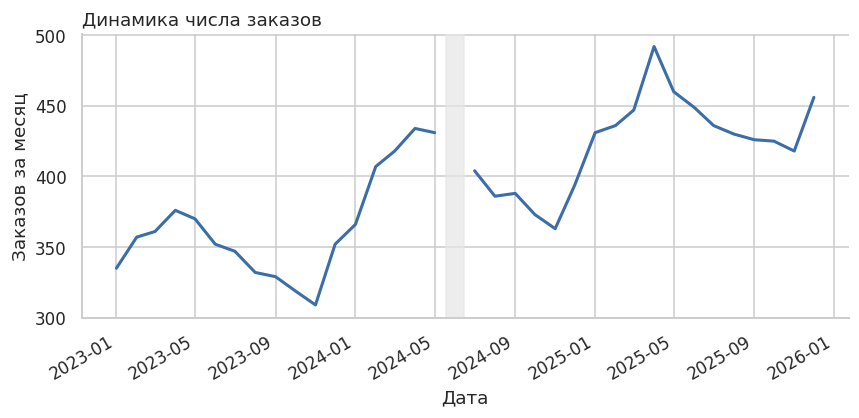

In [ ]:
figure = plt.figure(figsize=(9, 3.8))
axis = figure.add_subplot()
axis.plot(orders_with_gap["Месяц"], orders_with_gap["Всего заказов"], color=palette["Онлайн"], linewidth=2)
axis.axvspan(missing_month - pd.Timedelta(days=14), missing_month + pd.Timedelta(days=14), color="#E6E6E6", alpha=0.7)
axis.set_title("Динамика числа заказов", loc="left")
axis.set_ylabel("Заказов за месяц")
axis.set_xlabel("Дата")
axis.spines[["top", "right"]].set_visible(False)
figure.autofmt_xdate()
plt.show()

#### Составное сравнение

Другой вопрос: как менялись онлайн и офлайн-заказы?

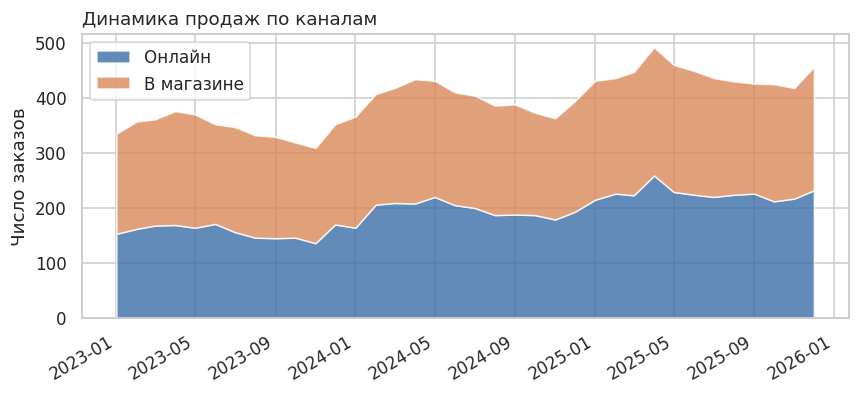

In [ ]:
figure = plt.figure(figsize=(9, 3.8))
axis = figure.add_subplot()
axis.stackplot(monthly_data["Месяц"], monthly_data["Онлайн"], monthly_data["В магазине"], labels=["Онлайн", "В магазине"], colors=[palette["Онлайн"], palette["В магазине"]], alpha=0.8)
axis.set_title("Динамика продаж по каналам", loc="left")
axis.set_ylabel("Число заказов")
axis.legend(loc="upper left")
figure.autofmt_xdate()
plt.show()

Две линии позволяют сравнить изменения в каналах продаж

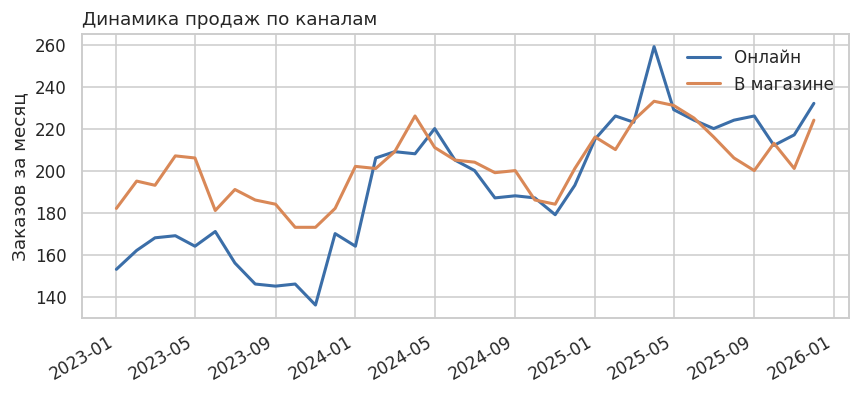

In [ ]:
figure = plt.figure(figsize=(9, 3.8))
axis = figure.add_subplot()
axis.plot(monthly_data["Месяц"], monthly_data["Онлайн"], label="Онлайн", color=palette["Онлайн"], linewidth=2)
axis.plot(monthly_data["Месяц"], monthly_data["В магазине"], label="В магазине", color=palette["В магазине"], linewidth=2)
axis.set_title("Динамика продаж по каналам", loc="left")
axis.set_ylabel("Заказов за месяц")
axis.legend(frameon=False)
figure.autofmt_xdate()
plt.show()

А вот если вопрос — как менялся общий поток заказов и из каких каналов он состоял? — составная площадь уместна: её верхняя граница отражает сумму.


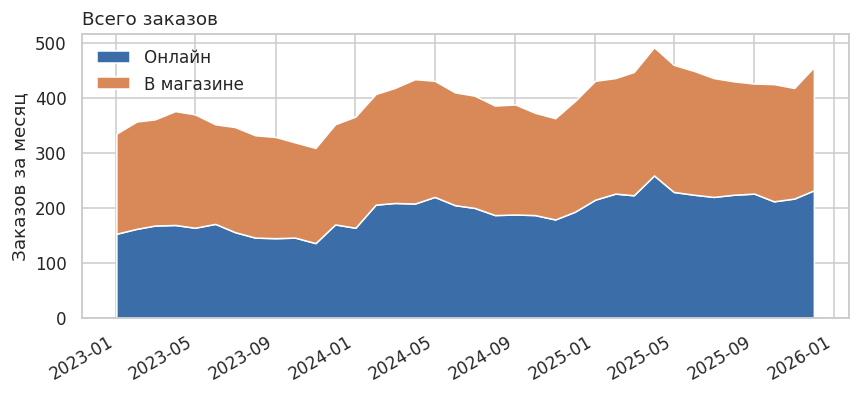

In [ ]:
figure = plt.figure(figsize=(9, 3.8))
axis = figure.add_subplot()
axis.stackplot(monthly_data["Месяц"], monthly_data["Онлайн"], monthly_data["В магазине"], labels=["Онлайн", "В магазине"], colors=[palette["Онлайн"], palette["В магазине"]])
axis.set_ylim(bottom=0)
axis.set_title("Всего заказов", loc="left")
axis.set_ylabel("Заказов за месяц")
axis.legend(loc="upper left", frameon=False)
figure.autofmt_xdate()
plt.show()

Можно ли совместить общий объем заказов и объем онлайн-заказов?

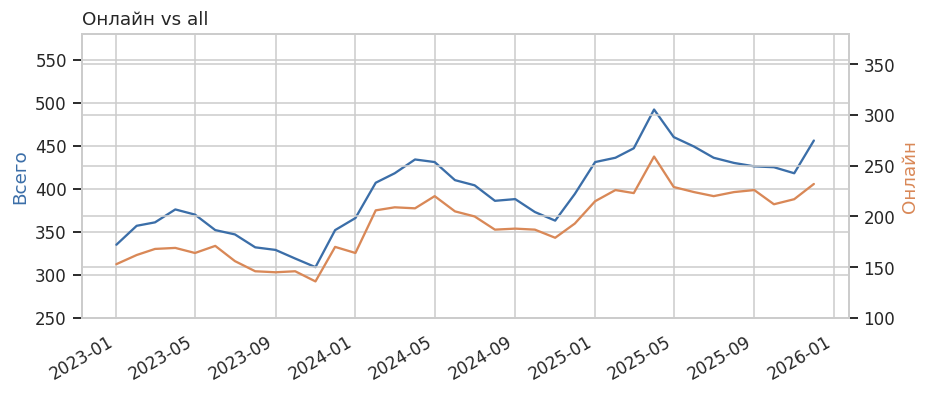

In [ ]:
figure = plt.figure(figsize=(9, 3.8))
left_ax = figure.add_subplot()
right_ax = left_ax.twinx()
left_ax.plot(monthly_data["Месяц"], monthly_data["Всего заказов"], color=palette["Онлайн"])
right_ax.plot(monthly_data["Месяц"], monthly_data["Онлайн"], color=palette["В магазине"])
left_ax.set_ylim(250, 580)
right_ax.set_ylim(100, 380)
left_ax.set_ylabel("Всего", color=palette["Онлайн"])
right_ax.set_ylabel("Онлайн", color=palette["В магазине"])
left_ax.set_title("Онлайн vs all", loc="left")
figure.autofmt_xdate()
plt.show()

Вместо двойного графика лучше показать два рисунка рядом с общей временной осью

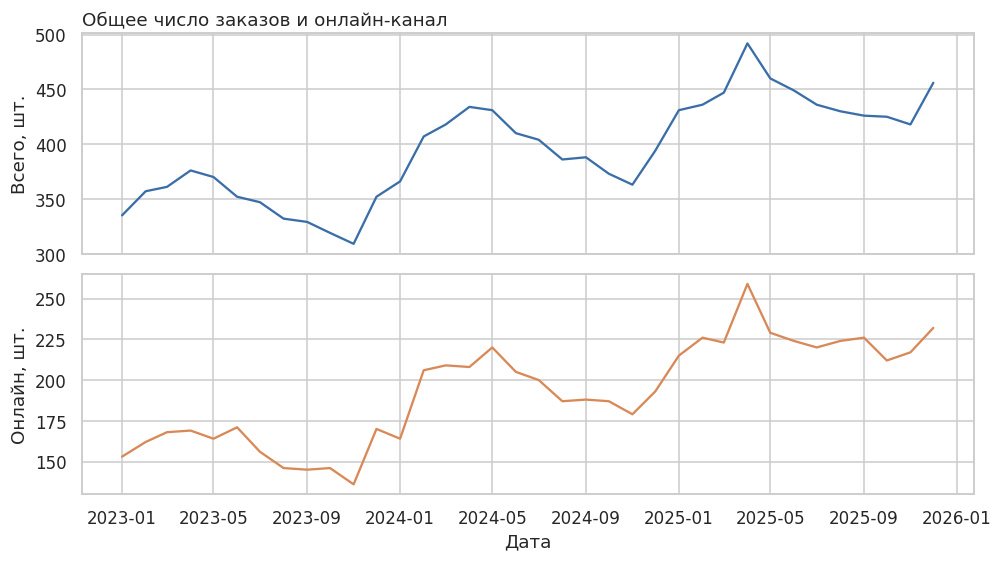

In [ ]:
figure = plt.figure(figsize=(9, 5), layout="constrained")
axes = figure.subplots(2, 1, sharex=True)
axes[0].plot(monthly_data["Месяц"], monthly_data["Всего заказов"], color=palette["Онлайн"])
axes[0].set_ylabel("Всего, шт.")
axes[0].set_title("Общее число заказов и онлайн-канал", loc="left")
axes[1].plot(monthly_data["Месяц"], monthly_data["Онлайн"], color=palette["В магазине"])
axes[1].set_ylabel("Онлайн, шт.")
axes[1].set_xlabel("Дата")
plt.show()

#### Часть от целого

Круговые диаграммы уместны, когда **все категории образуют одно и то же целое** и важна идея состава, а не точное сравнение близких величин.

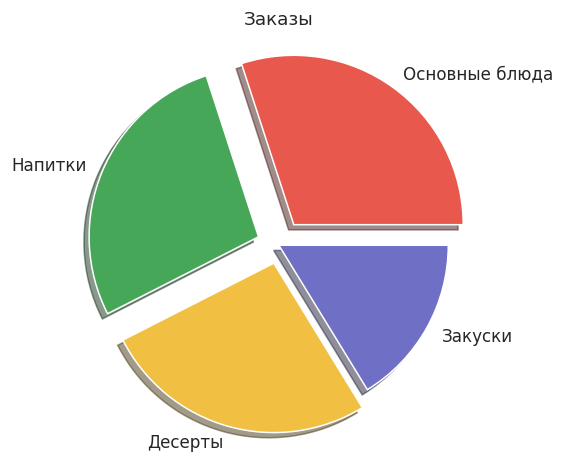

In [ ]:
figure = plt.figure(figsize=(6, 5))
axis = figure.add_subplot()
axis.pie(category_data["Заказы"], labels=category_data["Категория"], explode=[0.15, 0.13, 0.11, 0.0], shadow=True, colors=["#E8584D", "#46A758", "#F1BF42", "#6F6FC5"])
axis.set_title("Заказы")
plt.show()

- Тени и выдвинутые сектора не помогают чтению
- Надписи трудно соотнести с долями
- Сама геометрия круга плохо помогает понять разницу между близкими секторами

Вероятно, нас интересует вопрос - какую долю образует каждая категория?

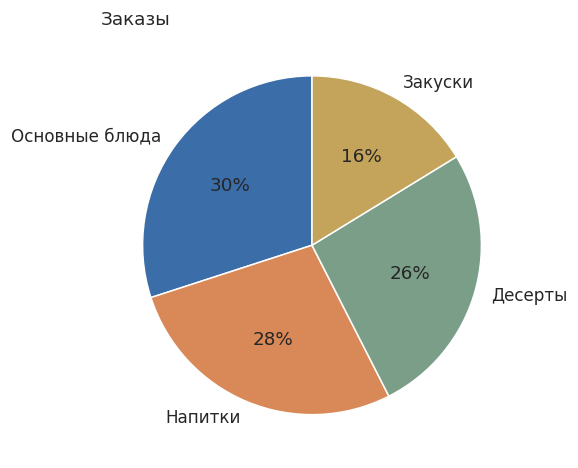

In [ ]:
total_category_orders = category_data["Заказы"].sum()
figure = plt.figure(figsize=(6, 5))
axis = figure.add_subplot()
axis.pie(category_data["Заказы"], labels=category_data["Категория"], autopct="%1.0f%%", startangle=90, colors=["#3B6EA8", "#D98857", "#7B9E89", "#C4A35A"], wedgeprops={"edgecolor": "white"})
axis.set_title(f"Заказы", loc="left")
plt.show()

#### Сравнение и сумма

В двух периодах есть значения по четырём категориям. Если цель **сравнить значения категории между периодами**, лучше поместить их рядом.

Накопленные столбцы пригодятся для другой цели - сравнение общего объёма и состава периодов.

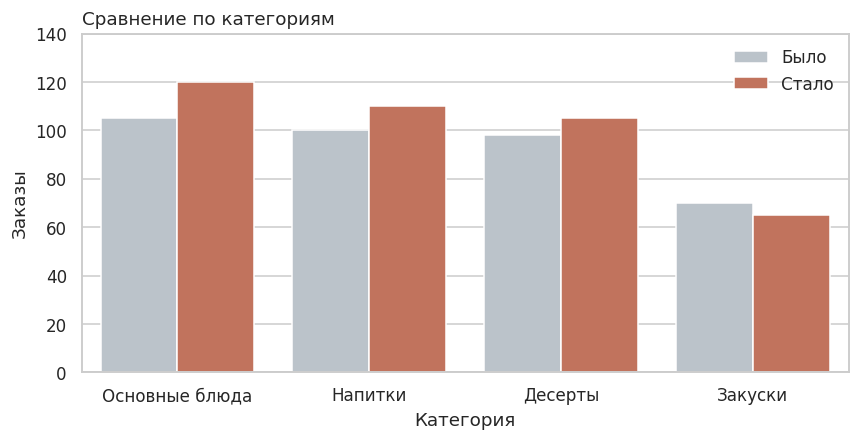

In [ ]:
long_period_data = period_data.melt(id_vars="Категория", value_vars=["Было", "Стало"], var_name="Период", value_name="Заказы")
figure = plt.figure(figsize=(9, 4))
axis = figure.add_subplot()
sns.barplot(data=long_period_data, x="Категория", y="Заказы", hue="Период", palette={"Было": neutral_color, "Стало": accent_color}, errorbar=None, ax=axis)
axis.set_ylim(0, 140)
axis.set_ylabel("Заказы")
axis.set_title("Сравнение по категориям", loc="left")
axis.legend(frameon=False)
plt.show()

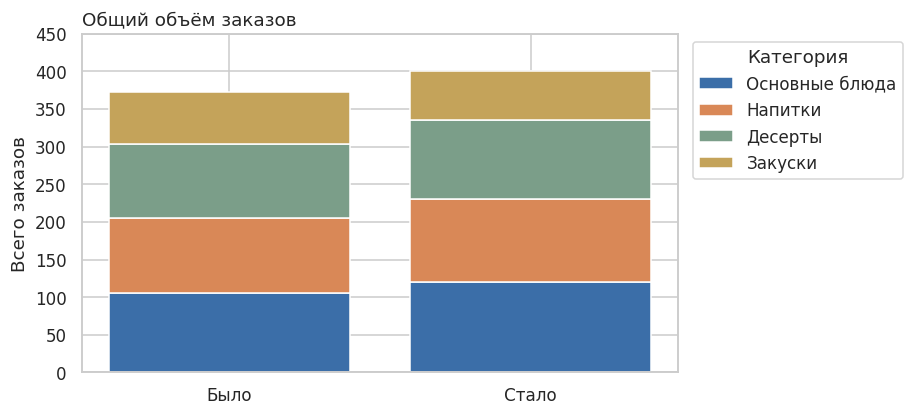

In [ ]:
period_totals = period_data[["Было", "Стало"]].sum()
figure = plt.figure(figsize=(7, 4))
axis = figure.add_subplot()
bar_bottom = np.zeros(len(period_totals))
for row in period_data.itertuples(index=False):
    category_heights = np.array([row.Было, row.Стало])
    axis.bar(period_totals.index, category_heights, bottom=bar_bottom, label=row.Категория, color={"Основные блюда": "#3B6EA8", "Напитки": "#D98857", "Десерты": "#7B9E89", "Закуски": "#C4A35A"}[row.Категория])
    bar_bottom = bar_bottom + category_heights
axis.set_ylim(0, 450)
axis.set_ylabel("Всего заказов")
axis.set_title("Общий объём заказов", loc="left")
axis.legend(title="Категория", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.show()

### Изучаем распределение признака

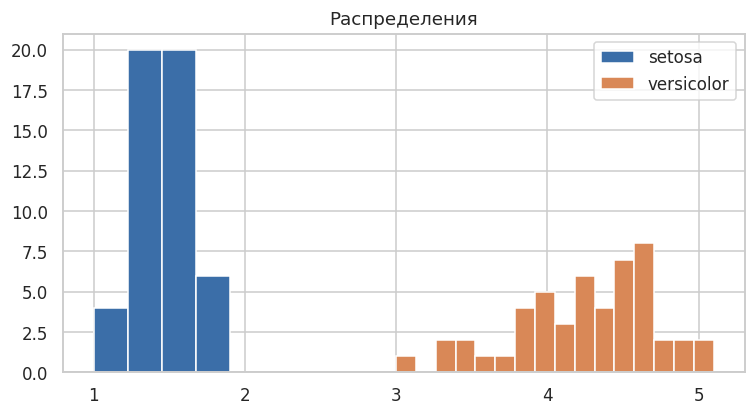

In [ ]:
setosa_lengths = iris_data.loc[iris_data["Вид"] == "setosa", "Длина лепестка, см"]
versicolor_lengths = iris_data.loc[iris_data["Вид"] == "versicolor", "Длина лепестка, см"]
figure = plt.figure(figsize=(8, 4))
axis = figure.add_subplot()
axis.hist(setosa_lengths, bins=4, color=palette["Онлайн"], label="setosa")
axis.hist(versicolor_lengths, bins=16, color=palette["В магазине"], label="versicolor")
axis.set_title("Распределения")
axis.legend()
plt.show()

- Две группы сравниваются с разной шириной интервала  - это затрудняет сравнение
- Непонятно, что сравнивается

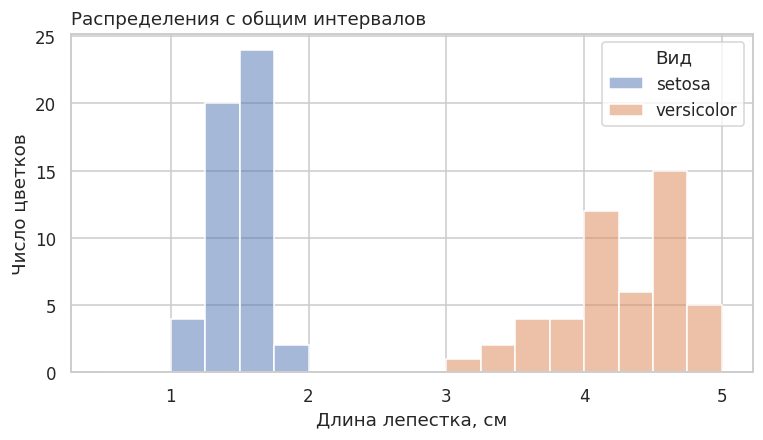

In [ ]:
common_edges = np.arange(0.5, 5.1, 0.25)
figure = plt.figure(figsize=(8, 4))
axis = figure.add_subplot()
sns.histplot(data=iris_data.loc[iris_data["Вид"].isin(["setosa", "versicolor"])], x="Длина лепестка, см", hue="Вид", bins=common_edges, stat="count", multiple="layer", alpha=0.5, ax=axis)
axis.set_title("Распределения с общим интервалов", loc="left")
axis.set_ylabel("Число цветков")
plt.show()

#### Сглаженная кривая - kde

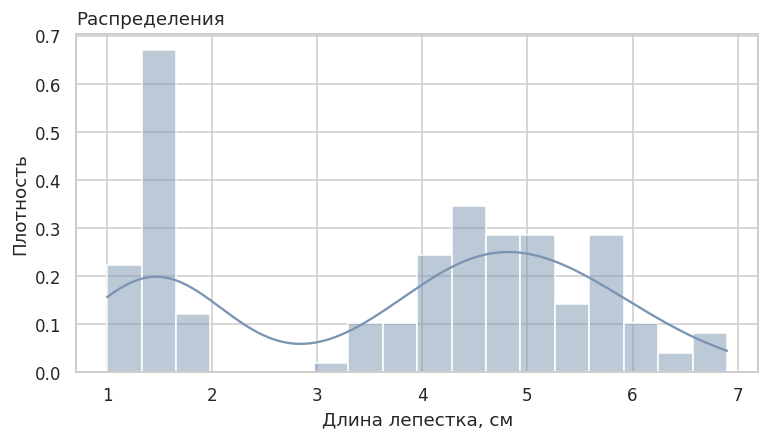

In [ ]:
figure = plt.figure(figsize=(8, 4))
axis = figure.add_subplot()
sns.histplot(data=iris_data, x="Длина лепестка, см", bins=18, stat="density", kde=True, color=category_color, ax=axis)
axis.set_title("Распределения", loc="left")
axis.set_ylabel("Плотность")
plt.show()

KDE добавляет сглаженную оценку существующих данных

#### Box plot - ящик с усами


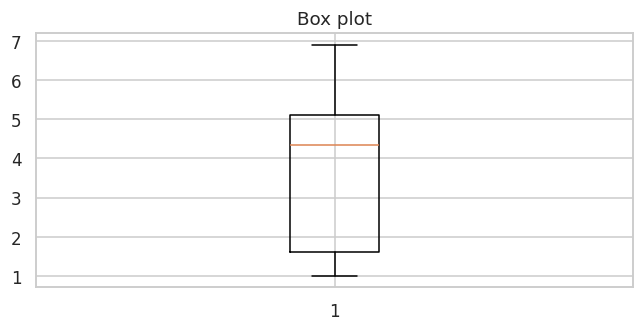

In [ ]:
figure = plt.figure(figsize=(7, 3))
axis = figure.add_subplot()
axis.boxplot(iris_data["Длина лепестка, см"])
axis.set_title("Box plot")
plt.show()

Непонятно, какая величина измерена, сколько наблюдений и что означает ящик...

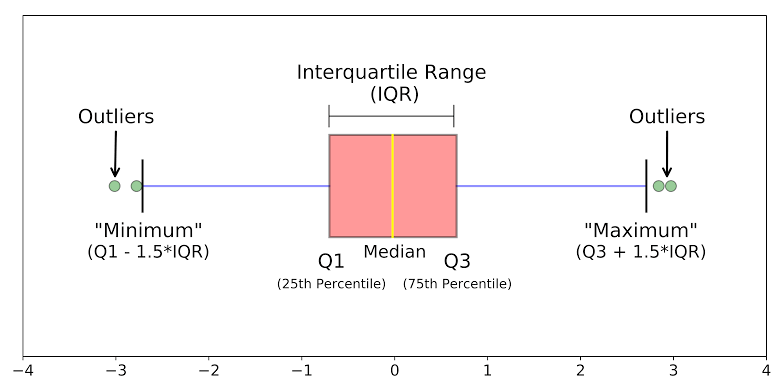

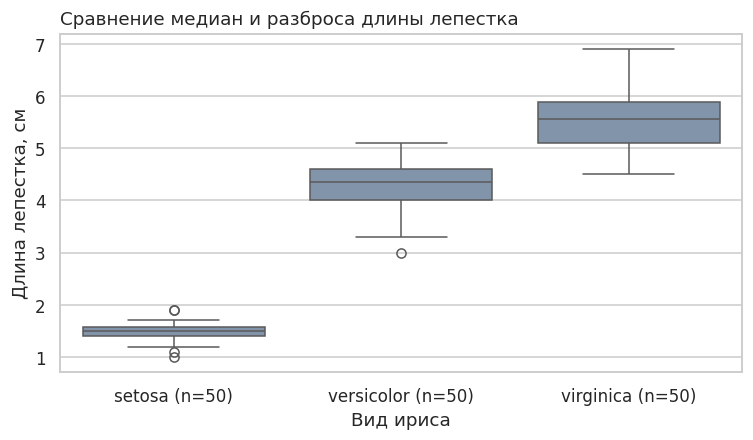

In [ ]:
species_counts = iris_data["Вид"].value_counts()
figure = plt.figure(figsize=(8, 4))
axis = figure.add_subplot()
sns.boxplot(data=iris_data, x="Вид", y="Длина лепестка, см", color=category_color, ax=axis)
axis.set_xticks(range(len(iris_bundle.target_names)), [f"{species} (n={species_counts[species]})" for species in iris_bundle.target_names])
axis.set_xlabel("Вид ириса")
axis.set_title("Сравнение медиан и разброса длины лепестка", loc="left")
plt.show()

#### Violin plot

Показывает сглаженную оценку формы распределения. Однако, сглаживание может придать небольшим группам мнимую плавность, а ширина может зависеть от настроек библиотеки

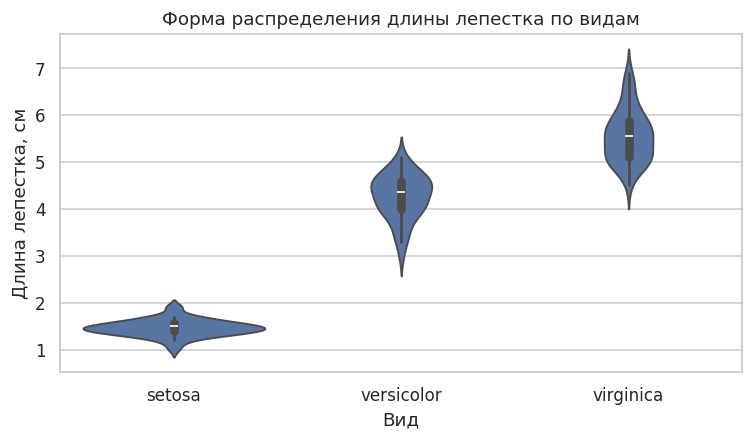

In [ ]:
figure = plt.figure(figsize=(8, 4))
axis = figure.add_subplot()
sns.violinplot(data=iris_data, x="Вид", y="Длина лепестка, см", ax=axis)
axis.set_title("Форма распределения длины лепестка по видам")
plt.show()

#### Отдельные точки

Когда наблюдений немного, показать каждое измерение бывает честнее, чем выбирать способ сглаживания. `stripplot`  накладывает точки с небольшим визуальным сдвигом, чтобы одинаковые или близкие значения не скрывали друг друга

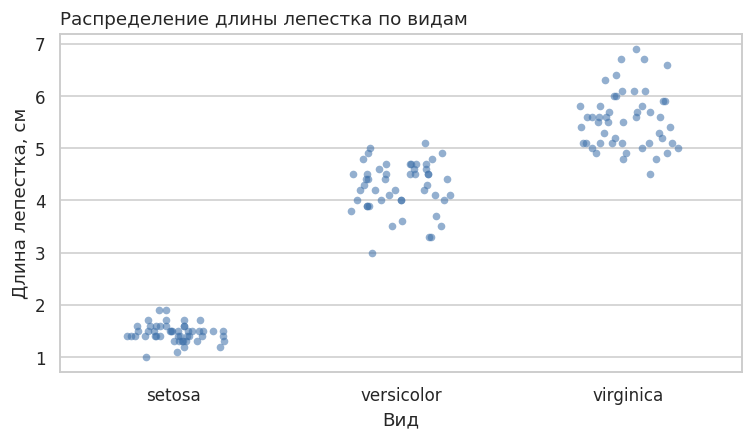

In [ ]:
figure = plt.figure(figsize=(8, 4))
axis = figure.add_subplot()
sns.stripplot(data=iris_data, x="Вид", y="Длина лепестка, см", jitter=0.22, alpha=0.55, color=palette["Онлайн"], ax=axis)
axis.set_title("Распределение длины лепестка по видам", loc="left")
plt.show()

### Связи, таблицы и сравнение двух состояний

#### Scatter plot

Вопрос - как связаны длина и ширина лепестка у ирисов?

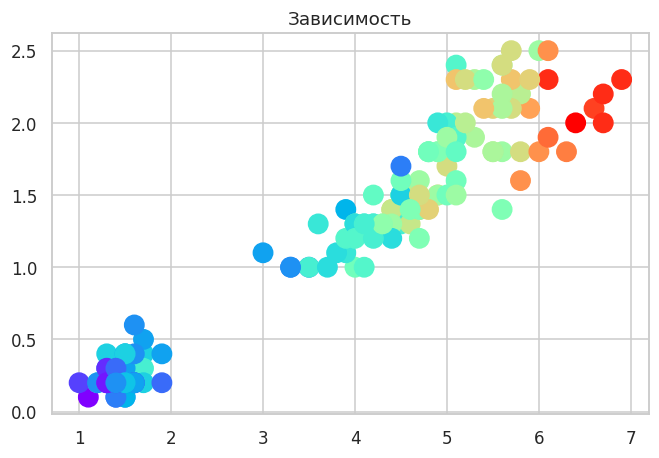

In [ ]:
figure = plt.figure(figsize=(7, 4.5))
axis = figure.add_subplot()
axis.scatter(iris_data["Длина лепестка, см"], iris_data["Ширина лепестка, см"], c=iris_data["Длина чашелистика, см"], cmap="rainbow", s=160, alpha=1)
axis.set_title("Зависимость")
plt.show()

- Крупные непрозрачные маркеры и непрозрачное кодирование цветом по ещё одной непрерывной величине, которая нам не нужна
- Красивый цветовой градиент отвлекает от вопроса
- Близкие точки перекрываются

Сам по себе наклон облака не доказывает причинную связь между измерениями!

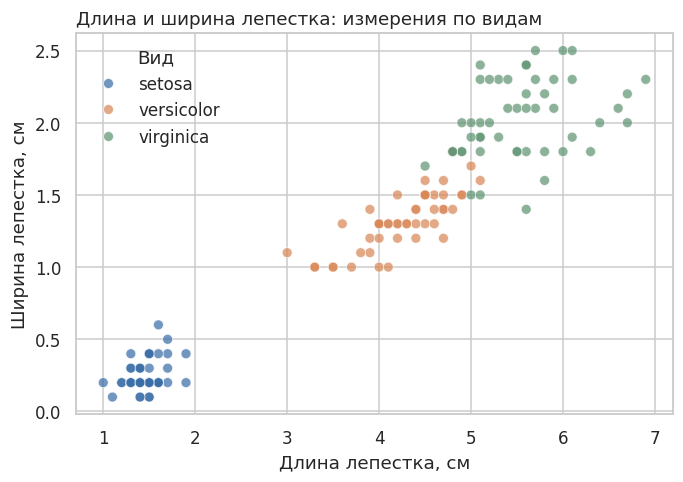

In [ ]:
species_palette = {"setosa": "#3B6EA8", "versicolor": "#D98857", "virginica": "#609474"}
figure = plt.figure(figsize=(7, 4.5))
axis = figure.add_subplot()
sns.scatterplot(data=iris_data, x="Длина лепестка, см", y="Ширина лепестка, см", hue="Вид", palette=species_palette, alpha=0.72, s=42, ax=axis)
axis.set_title("Длина и ширина лепестка: измерения по видам", loc="left")
axis.legend(title="Вид", frameon=False)
plt.show()

#### Тепловая карта

Вопрос - как менялся общий объем заказов по годам и месяцам?

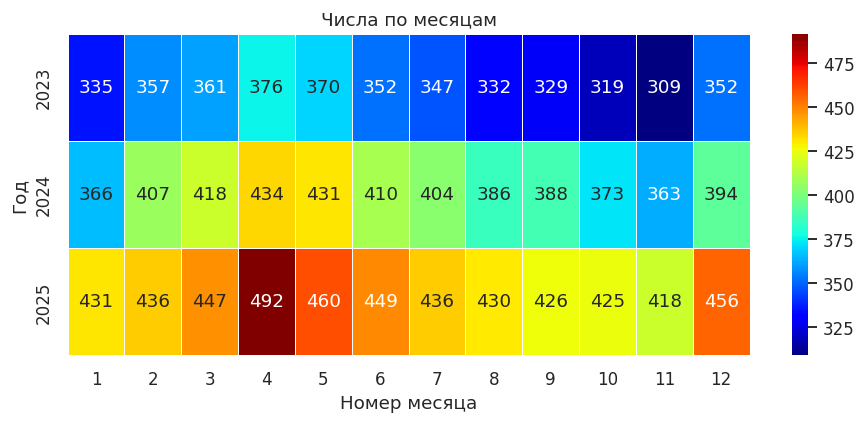

In [ ]:
year_month_orders = monthly_data.pivot(index="Год", columns="Номер месяца", values="Всего заказов")
figure = plt.figure(figsize=(10, 3.8))
axis = figure.add_subplot()
sns.heatmap(year_month_orders, cmap="jet", annot=True, fmt="d", linewidths=0.5, ax=axis)
axis.set_title("Числа по месяцам")
plt.show()

- Радуга и подробные числа в каждой клетке создают нагрузку
- Тепловая карта без упорядоченных осей и подписи цветовой шкалы не даёт интерпретируемого ответа

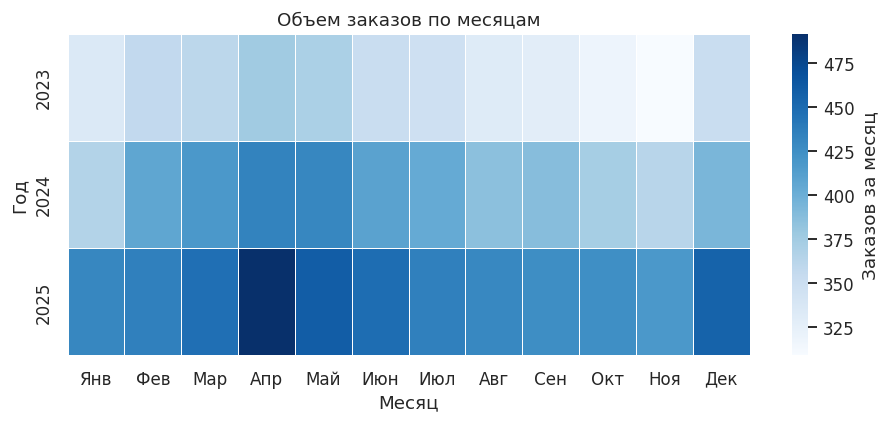

In [ ]:
figure = plt.figure(figsize=(10, 3.8))
axis = figure.add_subplot()
sns.heatmap(year_month_orders, cmap="Blues", cbar_kws={"label": "Заказов за месяц"}, linewidths=0.4, linecolor="white", ax=axis)
axis.set_xticklabels(["Янв", "Фев", "Мар", "Апр", "Май", "Июн", "Июл", "Авг", "Сен", "Окт", "Ноя", "Дек"], rotation=0)
axis.set_xlabel("Месяц")
axis.set_ylabel("Год")
axis.set_title("Объем заказов по месяцам")
plt.show()

#### Попарное изменение

Два значения на категорию можно показать сгруппированными столбцами, но если вопрос -** в каких категориях изменение между двумя периодами больше и каково его направление?**, график с точками, соединёнными отрезком, часто компактнее

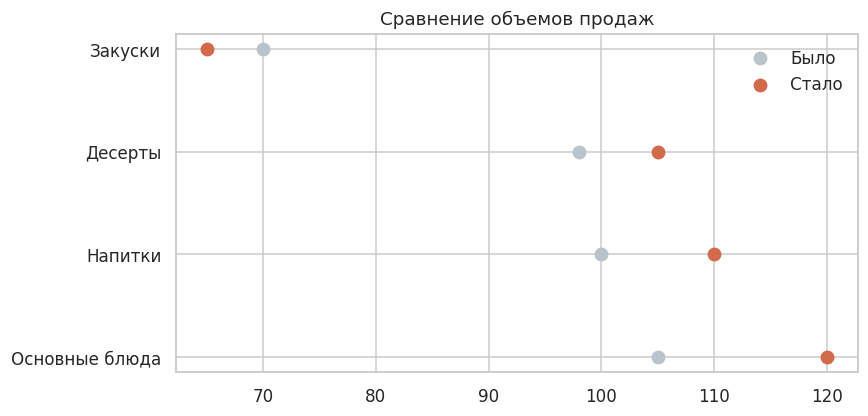

In [ ]:
figure = plt.figure(figsize=(8, 4))
axis = figure.add_subplot()
axis.scatter(period_data["Было"], period_data["Категория"], color=neutral_color, s=65, label="Было")
axis.scatter(period_data["Стало"], period_data["Категория"], color=accent_color, s=65, label="Стало")
axis.set_title("Сравнение объемов продаж")
axis.legend(frameon=False)
plt.show()

График показывает две группы маркеров, но вынуждает читателя мысленно искать пары

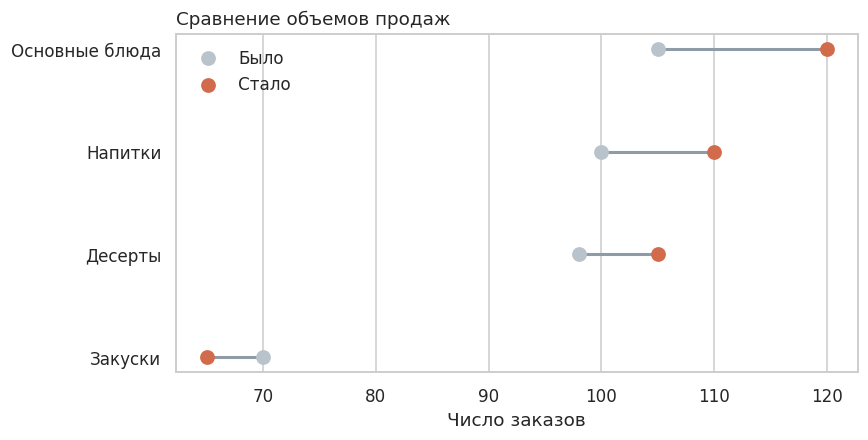

In [ ]:
sorted_periods = period_data.assign(Разница=period_data["Стало"] - period_data["Было"]).sort_values("Разница")
figure = plt.figure(figsize=(8, 4))
axis = figure.add_subplot()
for row in sorted_periods.itertuples(index=False):
    axis.plot([row.Было, row.Стало], [row.Категория, row.Категория], color="#8F9CA8", linewidth=2, zorder=1)
axis.scatter(sorted_periods["Было"], sorted_periods["Категория"], color=neutral_color, s=75, label="Было", zorder=2)
axis.scatter(sorted_periods["Стало"], sorted_periods["Категория"], color=accent_color, s=75, label="Стало", zorder=2)
axis.set_xlabel("Число заказов")
axis.set_title("Сравнение объемов продаж", loc="left")
axis.legend(frameon=False)
axis.grid(axis="y", visible=False)
plt.show()

### Более сложные графики

#### Pairplot

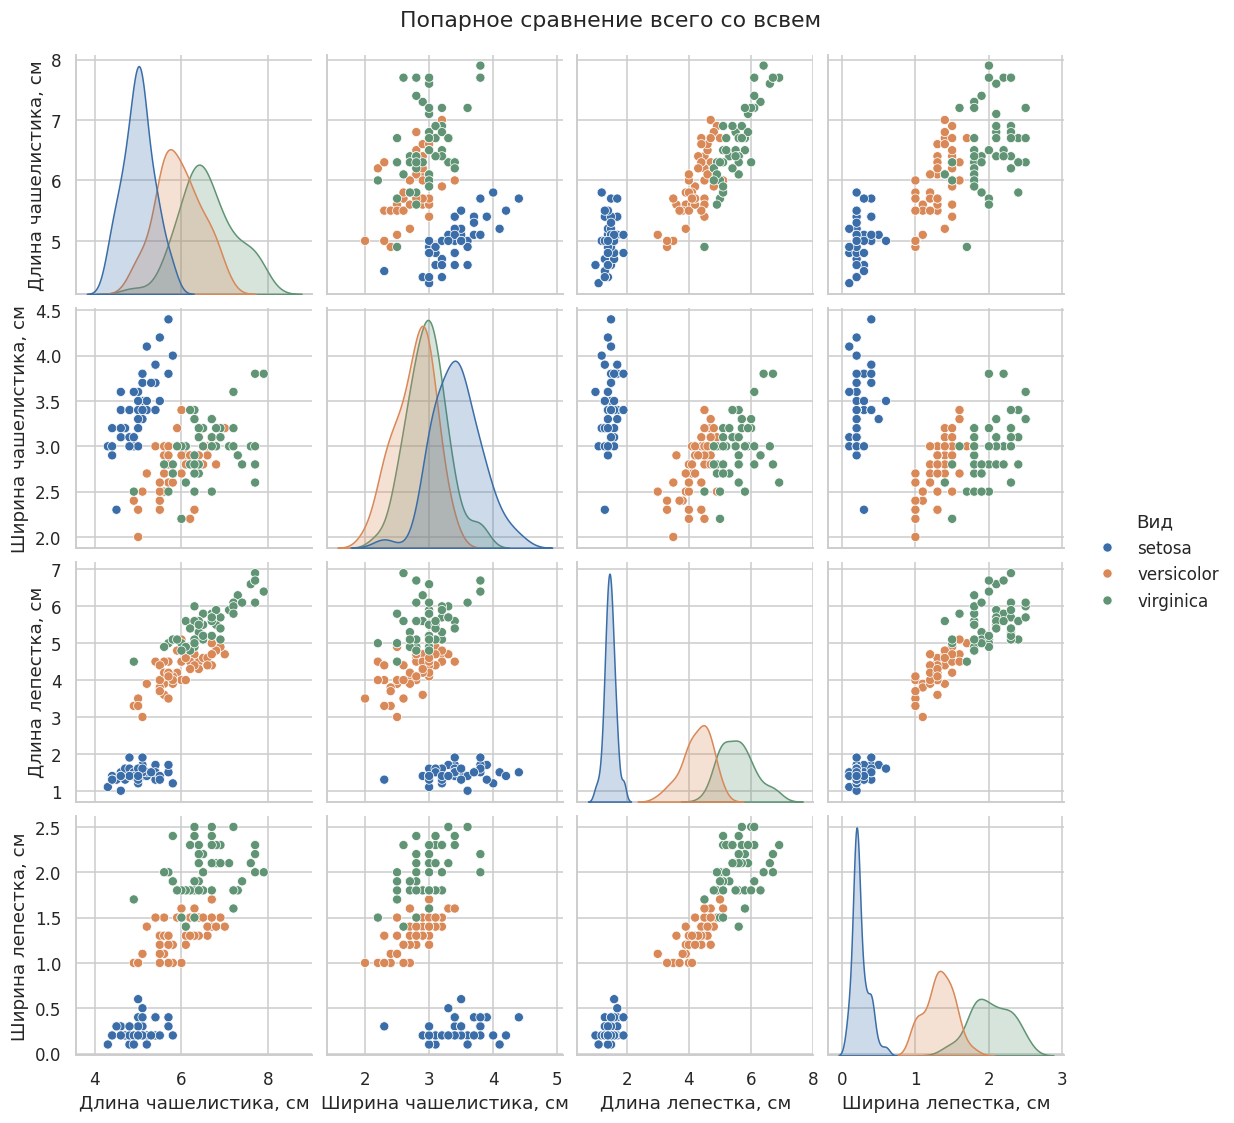

In [ ]:
pair_grid = sns.pairplot(data=iris_data, vars=["Длина чашелистика, см", "Ширина чашелистика, см", "Длина лепестка, см", "Ширина лепестка, см"], hue="Вид", palette=species_palette)
pair_grid.figure.suptitle("Попарное сравнение всего со всвем", y=1.02)
plt.show()

Несколько перегруженная сетка - что именно нужно сравнить?

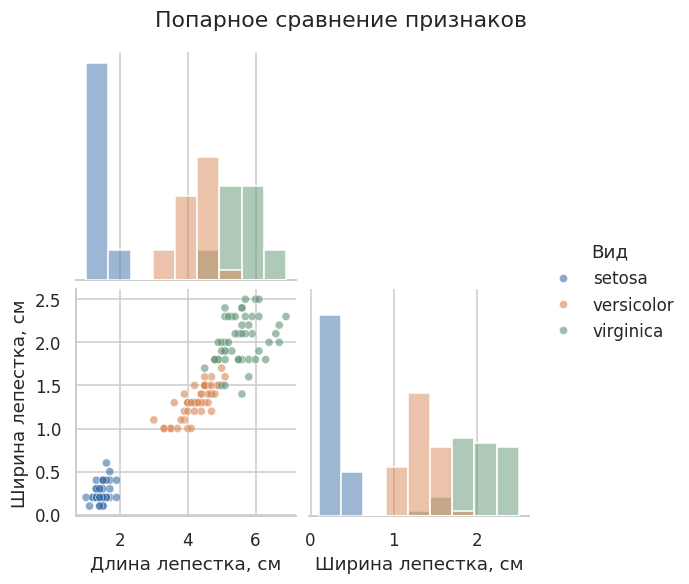

In [ ]:
pair_grid = sns.pairplot(data=iris_data, vars=["Длина лепестка, см", "Ширина лепестка, см"], hue="Вид", palette=species_palette, diag_kind="hist", corner=True, plot_kws={"alpha": 0.6, "s": 28})
pair_grid.figure.suptitle("Попарное сравнение признаков", y=1.05)
plt.show()

#### jointplot

По краям - частоты каждой величины

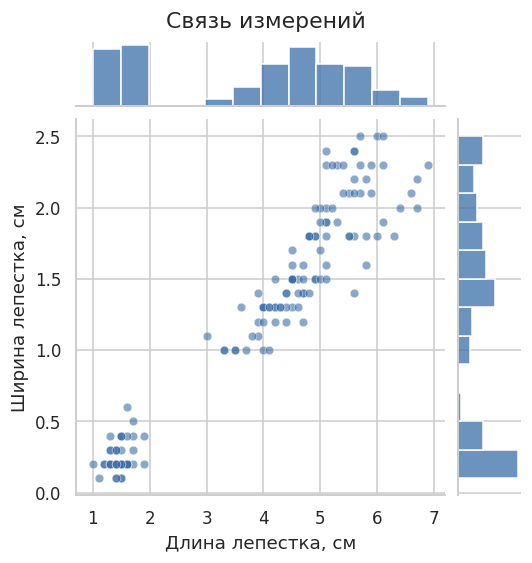

In [ ]:
joint_grid = sns.jointplot(data=iris_data, x="Длина лепестка, см", y="Ширина лепестка, см", kind="scatter", color=palette["Онлайн"], height=5, joint_kws={"alpha": 0.6, "s": 32}, marginal_kws={"bins": 12})
joint_grid.figure.suptitle("Связь измерений", y=1.02)
plt.show()

#### wordcloud

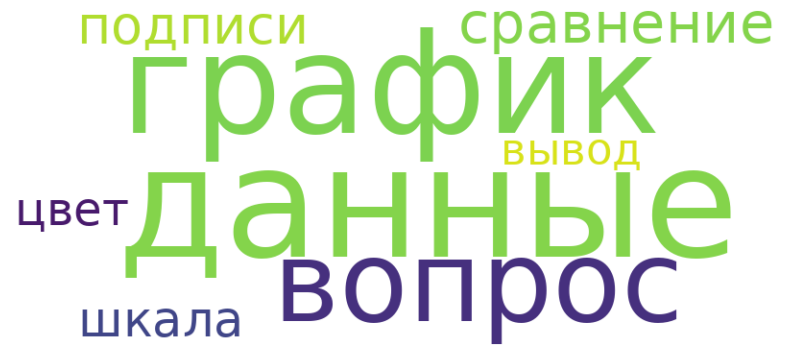

In [ ]:
from wordcloud import WordCloud
from matplotlib.font_manager import findfont

font_file = findfont("DejaVu Sans")
word_cloud = WordCloud(width=800, height=350, background_color="white", font_path=font_file, random_state=17, colormap="viridis").generate_from_frequencies(word_counts)
figure = plt.figure(figsize=(9, 4))
axis = figure.add_subplot()
axis.imshow(word_cloud, interpolation="bilinear")
axis.axis("off")
plt.show()

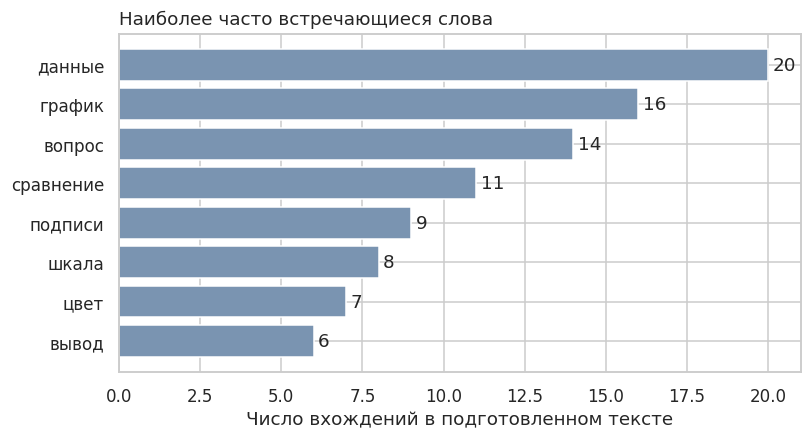

In [ ]:
sorted_words = pd.Series(word_counts).sort_values()
figure = plt.figure(figsize=(8, 4))
axis = figure.add_subplot()
axis.barh(sorted_words.index, sorted_words.values, color=category_color)
axis.set_xlabel("Число вхождений в подготовленном тексте")
axis.set_title("Наиболее часто встречающиеся слова", loc="left")
axis.bar_label(axis.containers[0], padding=3)
plt.show()